# TwinViews Text Probe Scoring

From `data/twinviews-13k.csv`: left-leaning vs right-leaning sentence pairs.
Interleave them and score each token with a DW-NOMINATE probe.
Visualize token scores as background colors (blue = Dem, red = Rep).

In [1]:
import json, os, sys, pickle, random
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import HTML, display
from transformers import AutoModelForImageTextToText, AutoProcessor

ROOT = Path.cwd()
if not (ROOT / "results").exists():
    ROOT = Path("/project/jevans/tzhang3/dotty-project/linear-political-llm")
sys.path.insert(0, str(ROOT))

In [2]:
MODEL_PATH = "/project/jevans/tzhang3/models/Qwen3-VL-8B-Instruct"
PROBE_PREFIX = "textual_ideology"
PROBE_TYPE = "headwise_linear"
TOP_K = 16

print("Loading model:", MODEL_PATH)
processor = AutoProcessor.from_pretrained(MODEL_PATH)
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_PATH, dtype=torch.bfloat16, device_map="auto",
).eval()
print("Model loaded.")

Loading model: /project/jevans/tzhang3/models/Qwen3-VL-8B-Instruct


Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

Model loaded.


In [3]:
# Load probe + build top-k runtime
probe_base = ROOT / "results" / "probes" / "qwen3-vl-8b-instruct"
weights_path = probe_base / f"{PROBE_PREFIX}_{PROBE_TYPE}_weights.pkl"
scores_path = probe_base / f"{PROBE_PREFIX}_{PROBE_TYPE}_scores.npy"

with open(weights_path, "rb") as f:
    weights = pickle.load(f)  # Dict[layer][head] = Ridge
scores = np.load(scores_path)  # [layers, heads]
print(f"Probe: {scores.shape[0]}L x {scores.shape[1]}H")
print(f"  Best head Spearman r: {scores.max():.4f}")

# Select top-k (layer, head) by absolute value
flat = scores.flatten()
top_flat = np.argsort(np.abs(flat))[-TOP_K:]
n_heads = scores.shape[1]
top_units = [(int(idx // n_heads), int(idx % n_heads)) for idx in top_flat]

# Build groups: module_name -> [(head_idx, coef_vec)]
groups = defaultdict(list)
for li, hi in top_units:
    name = f"model.language_model.layers.{li}.self_attn.head_out"
    coef = np.asarray(weights[li][hi].coef_, dtype=np.float32)
    groups[name].append((hi, coef))
normalizer = float(max(len(top_units), 1))
print(f"  Using top-{TOP_K} heads across {len(groups)} layers")

Probe: 36L x 32H
  Best head Spearman r: 0.8716
  Using top-16 heads across 5 layers


In [4]:
# Tokenize + score
def tokenize_text(text):
    # Tokenize raw text directly, no chat template
    enc = processor.tokenizer(text, return_tensors="pt")
    return {k: v.to(model.device) if isinstance(v, torch.Tensor) else v
            for k, v in enc.items()}

def score_tokens(inputs):
    named = dict(model.named_modules())
    captured = {}
    hooks = []
    for name in set(groups.keys()):
        def make_hook(n):
            def h(_m, _i, out):
                t = out[0] if isinstance(out, tuple) else out
                captured[n] = t.detach().to(dtype=torch.float32).cpu()
            return h
        hooks.append(named[name].register_forward_hook(make_hook(name)))
    with torch.no_grad():
        _ = model(**inputs)
    for hk in hooks:
        hk.remove()

    ts = None
    for mname, entries in groups.items():
        tout = captured[mname]  # [1, S, H, D]
        ms = None
        for hi, coef in entries:
            ct = torch.from_numpy(coef).to(device=tout.device, dtype=tout.dtype)
            hs = torch.einsum("b s d, d -> b s", tout[:, :, hi, :], ct)
            ms = hs if ms is None else ms + hs
        ts = ms if ts is None else ts + ms
    ts = (ts / normalizer).to(dtype=torch.float32).cpu().numpy()
    return ts[0]

def tokenize_and_score(text):
    inputs = tokenize_text(text)
    scores = score_tokens(inputs)
    ids = inputs["input_ids"][0].cpu().numpy()
    toks = [processor.tokenizer.decode([tid]) for tid in ids]
    if len(scores) > len(toks):
        scores = scores[:len(toks)]
    elif len(scores) < len(toks):
        scores = np.pad(scores, (0, len(toks)-len(scores)), constant_values=np.nan)
    return toks, scores

In [5]:
# Sanity check
t, s = tokenize_and_score("The government should provide universal healthcare.")
print(f"Tokens: {len(t)}, range: [{s.min():.4f}, {s.max():.4f}]")
for i in range(min(10, len(t))):
    print(f"  {t[i]:20s} {s[i]:+.4f}")

Tokens: 7, range: [-0.3982, 0.0028]
  The                  -0.0800
   government          +0.0028
   should              -0.0297
   provide             -0.0989
   universal           -0.3207
   healthcare          -0.3982
  .                    -0.3040


## Token-Level Visualization

Each token is colored: blue (negative = Democratic) → white → red (positive = Republican).

In [6]:
def score_to_color(score, vmax=0.5):
    if np.isnan(score):
        return "#e0e0e0"
    t = max(-1., min(1., score / vmax))
    if t <= 0:
        return f"#{int(255*(1+t)):02x}{int(255*(1+t)):02x}ff"
    else:
        return f"#ff{int(255*(1-t)):02x}{int(255*(1-t)):02x}"

def render_html(tokens, scores, vmax=0.5):
    parts = ['<div style="font-family:monospace; line-height:2.4; font-size:13px; max-width:900px; word-wrap:break-word;">']
    for tok, sc in zip(tokens, scores):
        bg = score_to_color(sc, vmax)
        esc = tok.replace("&","&amp;").replace("<","&lt;").replace(">","&gt;")
        parts.append(f'<span style="background:{bg}; padding:2px 1px; margin:0 1px; border-radius:2px;" title="{sc:.4f}">{esc}</span>')
    parts.append('</div>')
    return "".join(parts)

def side_by_side(left_text, right_text, vmax=0.5):
    lt, ls = tokenize_and_score(left_text)
    rt, rs = tokenize_and_score(right_text)
    print(f"  L mean: {np.nanmean(ls):+.4f}    R mean: {np.nanmean(rs):+.4f}")
    return HTML(
        '<table><tr>'
        '<td style="vertical-align:top; padding:6px; width:450px;">'
        f'<b style="color:#5bc0de;">Left</b><br>{render_html(lt, ls, vmax)}</td>'
        '<td style="vertical-align:top; padding:6px; width:450px;">'
        f'<b style="color:#d9534f;">Right</b><br>{render_html(rt, rs, vmax)}</td>'
        '</tr></table>')

## Example: Single Topic Pair

In [7]:
tv_path = ROOT / "data" / "twinviews-13k.csv"
tv_df = pd.read_csv(tv_path)
print(f"{len(tv_df)} sentence pairs, {tv_df['topic'].nunique()} topics")

row = tv_df[tv_df["topic"] == "Abortion Rights"].iloc[0]
print(f"\nTopic: {row['topic']}")
side_by_side(row["l"], row["r"])

13855 sentence pairs, 1024 topics

Topic: Abortion Rights
  L mean: -0.4792    R mean: +0.2452


LeftA woman should have the right to choose whether to have an abortion.,RightAbortion should be illegal and considered as taking a human life.


## Interleaved: L1, R1, L2, R2, ... across many topics

Tokens: 680


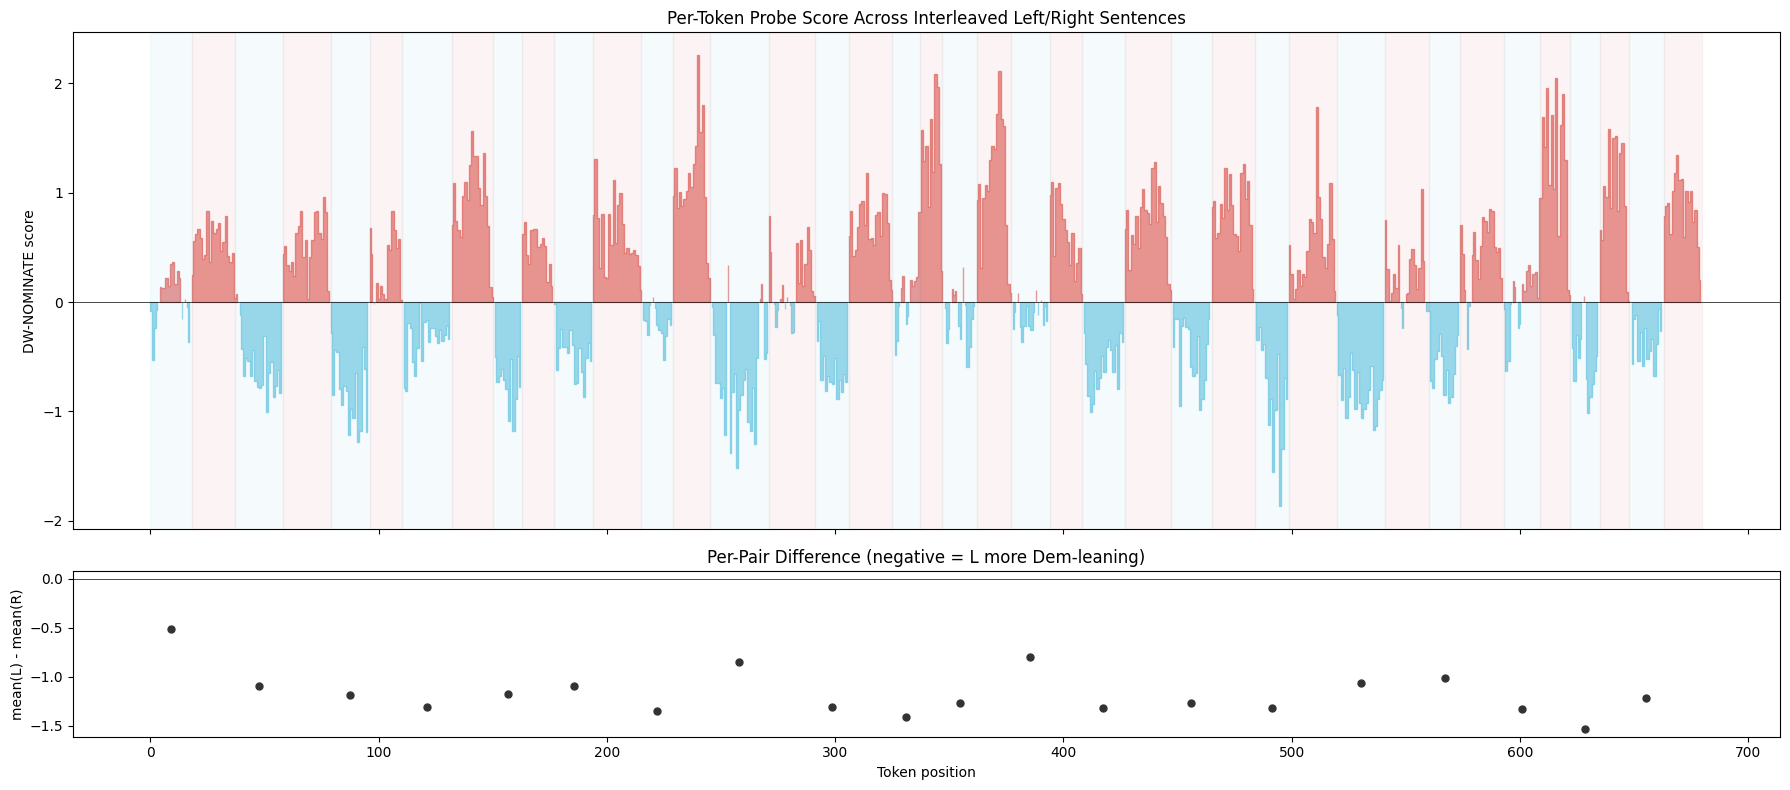

Overall mean: +0.1372
L - R (mean of per-pair diffs): -1.1703


In [8]:
random.seed(42)
sample = tv_df.sample(n=20, random_state=123).reset_index(drop=True)

parts = []
boundaries = []
pos = 0
for _, row in sample.iterrows():
    ltxt = f"LEFT: {row['l']}"
    rtxt = f"RIGHT: {row['r']}"
    lt, _ = tokenize_and_score(ltxt)
    rt, _ = tokenize_and_score(rtxt)
    parts.append(ltxt)
    parts.append(rtxt)
    boundaries.append((pos, "L", row["topic"]))
    pos += len(lt)
    boundaries.append((pos, "R", row["topic"]))
    pos += len(rt)

full = " ".join(parts)
tokens, scores = tokenize_and_score(full)
print(f"Tokens: {len(tokens)}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 8), sharex=True,
                               gridspec_kw={"height_ratios": [3, 1]})
x = np.arange(len(scores))
ax1.fill_between(x, 0, scores, where=scores > 0, color="#d9534f", alpha=0.6, step="mid")
ax1.fill_between(x, 0, scores, where=scores < 0, color="#5bc0de", alpha=0.6, step="mid")
ax1.axhline(0, color="black", linewidth=0.5)
ax1.set_ylabel("DW-NOMINATE score")
ax1.set_title("Per-Token Probe Score Across Interleaved Left/Right Sentences")

for i in range(len(boundaries)):
    bpos, bside, btop = boundaries[i]
    next_b = boundaries[i+1][0] if i+1 < len(boundaries) else len(scores)
    color = "#5bc0de" if bside == "L" else "#d9534f"
    ax1.axvspan(bpos, min(next_b, len(scores)), alpha=0.06, color=color)

diffs = []
for i in range(0, len(boundaries), 2):
    if i+1 < len(boundaries):
        ls = scores[boundaries[i][0]:boundaries[i+1][0]]
        rs_end = boundaries[i+2][0] if i+2 < len(boundaries) else len(scores)
        rs = scores[boundaries[i+1][0]:rs_end]
        d = np.nanmean(ls) - np.nanmean(rs)
        diffs.append(d)
        mid = (boundaries[i][0] + boundaries[i+1][0]) / 2
        ax2.scatter(mid, d, c="#333", s=25, zorder=5)

ax2.axhline(0, color="black", linewidth=0.5)
ax2.set_ylabel("mean(L) - mean(R)")
ax2.set_xlabel("Token position")
ax2.set_title("Per-Pair Difference (negative = L more Dem-leaning)")
plt.tight_layout()
plt.show()

print(f"Overall mean: {np.nanmean(scores):+.4f}")
print(f"L - R (mean of per-pair diffs): {np.mean(diffs):+.4f}")

## Interleaved HTML: Colored Tokens Across L/R Pairs

Same interleaved text rendered with token-level color: blue = Dem-leaning, red = Rep-leaning.

In [9]:
few = tv_df.sample(n=5, random_state=99).reset_index(drop=True)

html_parts = ['<div style="font-family:monospace; line-height:2.2; font-size:13px; max-width:900px;">']
for _, row in few.iterrows():
    html_parts.append(f'<div style="margin-top:10px; font-weight:bold; color:#666;">{row["topic"]}</div>')
    for side, clr in [("l", "#5bc0de"), ("r", "#d9534f")]:
        label = "L" if side == "l" else "R"
        toks, scs = tokenize_and_score(row[side])
        mean_s = np.nanmean(scs)
        html_parts.append(
            f'<span style="color:{clr}; font-weight:bold; margin-right:6px;">'
            f'[{label}] {mean_s:+.4f}</span>')
        for tok, sc in zip(toks, scs):
            bg = score_to_color(sc, 0.5)
            esc = tok.replace("&","&amp;").replace("<","&lt;").replace(">","&gt;")
            html_parts.append(
                f'<span style="background-color:{bg}; padding:2px 1px; margin:0 1px; '
                f'border-radius:2px;" title="{sc:.4f}">{esc}</span>')
        html_parts.append('<br>')
html_parts.append('</div>')
display(HTML("".join(html_parts)))

## Batch: Distribution of Sentence-Level Means

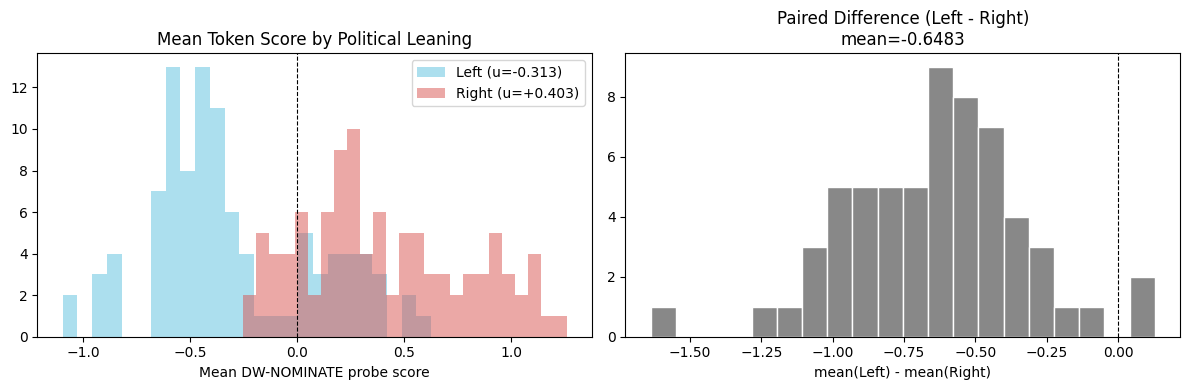

Paired t-test: t=-16.457, p=6.44e-24
Left mean:  -0.2975
Right mean: +0.3509


In [10]:
batch = tv_df.sample(n=100, random_state=42)
rows = []
for _, row in batch.iterrows():
    _, ls = tokenize_and_score(row["l"])
    _, rs = tokenize_and_score(row["r"])
    rows.append({"topic": row["topic"], "mean_score": np.nanmean(ls), "side": "Left"})
    rows.append({"topic": row["topic"], "mean_score": np.nanmean(rs), "side": "Right"})

comp = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for side, c, ax in [("Left", "#5bc0de", axes[0]), ("Right", "#d9534f", axes[0])]:
    v = comp[comp["side"] == side]["mean_score"].dropna()
    ax.hist(v, bins=25, alpha=0.5, color=c, label=f"{side} (u={v.mean():+.3f})")
axes[0].axvline(0, color="black", linestyle="--", linewidth=0.8)
axes[0].set_title("Mean Token Score by Political Leaning")
axes[0].set_xlabel("Mean DW-NOMINATE probe score")
axes[0].legend()

# Paired difference
paired = comp.pivot_table(index="topic", columns="side", values="mean_score", aggfunc="mean").dropna()
paired["diff"] = paired["Left"] - paired["Right"]
axes[1].hist(paired["diff"], bins=20, color="#888888", edgecolor="white")
axes[1].axvline(0, color="black", linestyle="--", linewidth=0.8)
axes[1].set_title(f"Paired Difference (Left - Right)\nmean={paired['diff'].mean():+.4f}")
axes[1].set_xlabel("mean(Left) - mean(Right)")
plt.tight_layout()
plt.show()

from scipy import stats
if len(paired) > 2:
    t_stat, t_p = stats.ttest_1samp(paired["diff"], 0)
    print(f"Paired t-test: t={t_stat:.3f}, p={t_p:.3g}")
print(f"Left mean:  {paired['Left'].mean():+.4f}")
print(f"Right mean: {paired['Right'].mean():+.4f}")

## Image Canvas: Interleaved L/R Text Rendered as an Image

Render left/right sentences onto a PIL image canvas line by line,
then feed the image through the VLM and score the tokens.

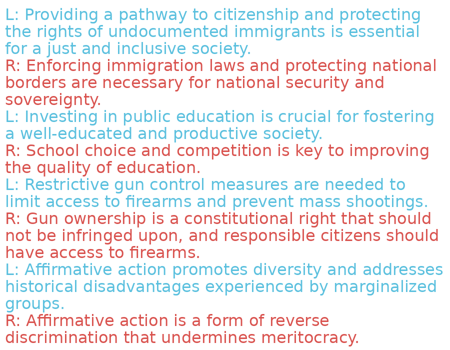

Canvas: (900, 700), 20 lines


In [21]:
from PIL import Image, ImageDraw, ImageFont

# Try to load a font, fall back to default
try:
    font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 32)
except (OSError, IOError):
    font = ImageFont.load_default()

# Build interleaved left/right lines
few = tv_df.sample(n=4, random_state=42).reset_index(drop=True)
lines = []
for _, row in few.iterrows():
    lines.append((f"L: {row['l']}", "#5bc0de"))
    lines.append((f"R: {row['r']}", "#d9534f"))

# Compute canvas size with word-wrapping
line_spacing = 4
max_width = 900
line_h = font.getbbox("Ag")[3] - font.getbbox("Ag")[1] + line_spacing

wrapped_lines = []
wrapped_colors = []
for text, clr in lines:
    words = text.split()
    cur = ""
    for w in words:
        test = cur + (" " if cur else "") + w
        if font.getbbox(test)[2] - font.getbbox(test)[0] > max_width - 20:
            wrapped_lines.append(cur)
            wrapped_colors.append(clr)
            cur = w
        else:
            cur = test
    if cur:
        wrapped_lines.append(cur)
        wrapped_colors.append(clr)

canvas_h = len(wrapped_lines) * line_h + 20
canvas = Image.new("RGB", (max_width, canvas_h), "white")
draw = ImageDraw.Draw(canvas)
y = 10
for text, clr in zip(wrapped_lines, wrapped_colors):
    draw.text((10, y), text, fill=clr, font=font)
    y += line_h

display(canvas.resize((max_width//2, canvas_h//2)))
print(f"Canvas: {canvas.size}, {len(wrapped_lines)} lines")

Vision grid: 22h x 28w  (resized: 704x896)
Image tokens: 616 (grid 22x28)
Image mean: +0.0798


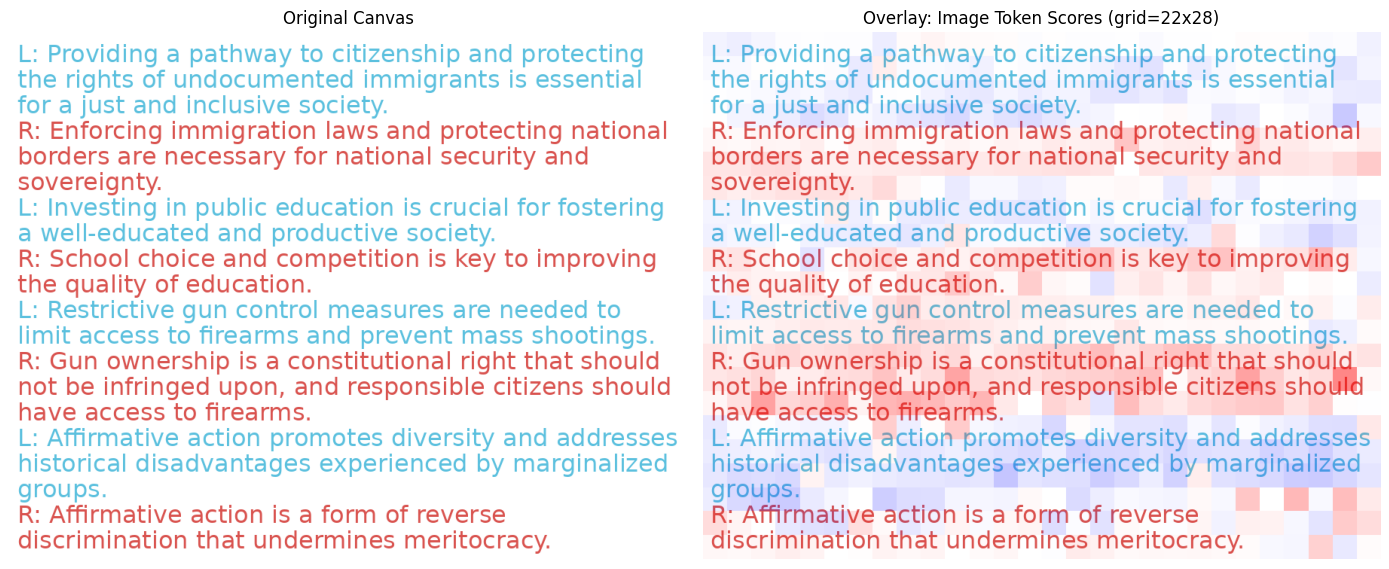

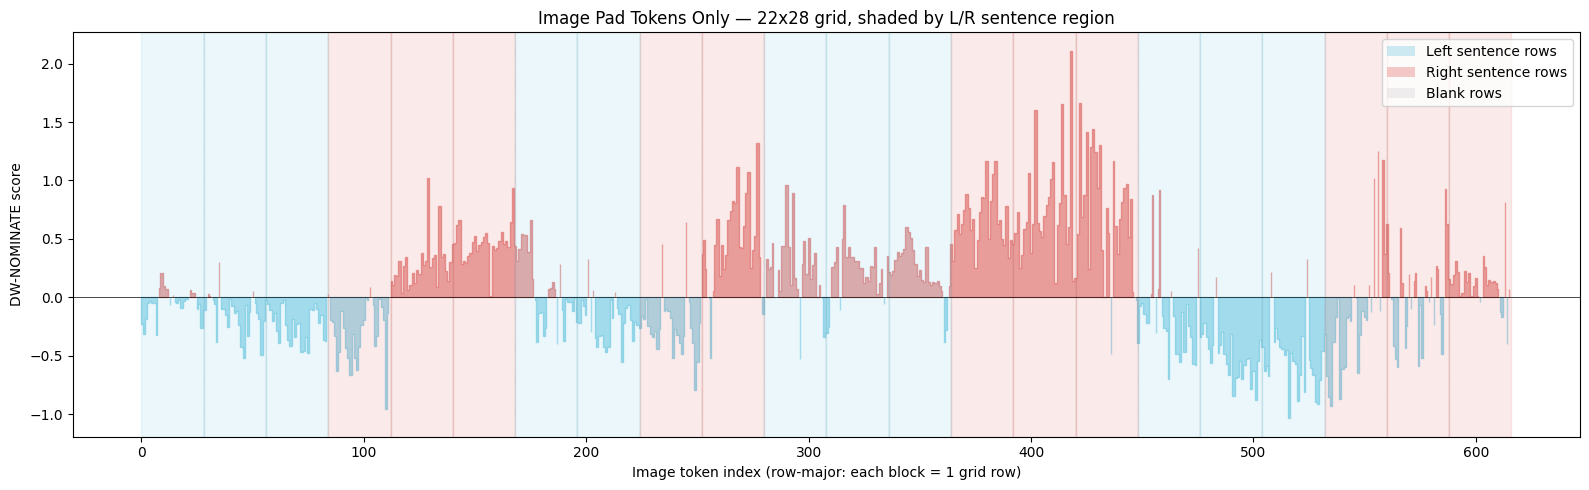

L rows (11): mean=-0.0948
R rows (11): mean=+0.2544


In [22]:
# Feed image through VLM and score
msgs = [{"role": "user", "content": [
    {"type": "image", "image": canvas},
    {"type": "text", "text": "What political perspectives are expressed in this image?"},
]}]
enc = processor.apply_chat_template(
    msgs, tokenize=True, add_generation_prompt=True,
    return_dict=True, return_tensors="pt",
)
inputs = {k: v.to(model.device) if isinstance(v, torch.Tensor) else v
          for k, v in enc.items()}

# Find image tokens
image_token_id = processor.tokenizer.convert_tokens_to_ids("<|image_pad|>")
input_ids = inputs["input_ids"][0].cpu().numpy()
is_image = (input_ids == image_token_id) if image_token_id is not None else np.zeros(len(input_ids), dtype=bool)

# Compute vision grid size (Qwen3-VL)
from transformers.models.qwen2_vl.image_processing_qwen2_vl import smart_resize
ip = processor.image_processor
patch = ip.patch_size if hasattr(ip, 'patch_size') else 14
merge = ip.merge_size if hasattr(ip, 'merge_size') else 2
factor = patch * merge
rh, rw = smart_resize(canvas.height, canvas.width, factor,
                      min_pixels=ip.size["shortest_edge"],
                      max_pixels=ip.size["longest_edge"])
gh, gw = rh // factor, rw // factor
print(f"Vision grid: {gh}h x {gw}w  (resized: {rh}x{rw})")

# Score
all_scores = score_tokens(inputs)
img_scores = all_scores[is_image]
n_img = int(is_image.sum())
print(f"Image tokens: {n_img} (grid {gh}x{gw})")
print(f"Image mean: {img_scores.mean():+.4f}")

# ---- Map image grid rows to L/R sentences ----
line_h = font.getbbox("Ag")[3] - font.getbbox("Ag")[1] + line_spacing
grid_row_height = rh / gh
row_side = [""] * gh
for li, clr in enumerate(wrapped_colors):
    y_start = 10 + li * line_h
    y_end = y_start + line_h - line_spacing
    row_start = int(y_start / grid_row_height)
    row_end = min(int(y_end / grid_row_height) + 1, gh)
    side = "L" if "#5bc0de" in clr else "R"
    for r in range(row_start, row_end):
        if 0 <= r < gh:
            row_side[r] = side

# ---- Overlay image token scores on canvas ----
img_grid = img_scores.reshape(gh, gw)
overlay = Image.new("RGBA", (gw, gh))
opx = overlay.load()
vmax = max(abs(img_grid.min()), abs(img_grid.max()), 1e-6)
for iy in range(gh):
    for ix in range(gw):
        v = img_grid[iy, ix]
        t = max(-1., min(1., v / vmax))
        if t <= 0:
            r, g, b, a = 0, 0, 255, int(120 * abs(t))
        else:
            r, g, b, a = 255, 0, 0, int(120 * abs(t))
        opx[ix, iy] = (r, g, b, a)
overlay = overlay.resize((canvas.width, canvas.height), Image.NEAREST)
result = canvas.convert("RGBA")
result = Image.alpha_composite(result, overlay).convert("RGB")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.imshow(canvas)
ax1.set_title("Original Canvas")
ax1.axis("off")
ax2.imshow(result)
ax2.set_title(f"Overlay: Image Token Scores (grid={gh}x{gw})")
ax2.axis("off")
plt.tight_layout()
plt.show()

# ---- Image-pad-only sequence plot with L/R sentence row shading ----
fig, ax = plt.subplots(figsize=(16, 5))
x = np.arange(n_img)
ax.fill_between(x, 0, img_scores, where=img_scores>0, color="#d9534f", alpha=0.5, step="mid")
ax.fill_between(x, 0, img_scores, where=img_scores<0, color="#5bc0de", alpha=0.5, step="mid")

# Shade each grid row by L/R sentence
for grid_row in range(gh):
    side = row_side[grid_row]
    if side == "L":
        color = "#5bc0de"
    elif side == "R":
        color = "#d9534f"
    else:
        color = "#cccccc"
    t0 = grid_row * gw
    t1 = t0 + gw
    ax.axvspan(t0, t1, alpha=0.12, color=color)

# Row boundaries
for r in range(1, gh):
    ax.axvline(r * gw, color="#888888", linewidth=0.3, linestyle=":")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#5bc0de", alpha=0.3, label="Left sentence rows"),
    Patch(facecolor="#d9534f", alpha=0.3, label="Right sentence rows"),
    Patch(facecolor="#cccccc", alpha=0.3, label="Blank rows"),
]
ax.legend(handles=legend_elements, loc="upper right")

ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Image token index (row-major: each block = 1 grid row)")
ax.set_ylabel("DW-NOMINATE score")
ax.set_title(f"Image Pad Tokens Only — {gh}x{gw} grid, shaded by L/R sentence region")
plt.tight_layout()
plt.show()

# Per-row mean
l_rows = [img_grid[r, :].mean() for r in range(gh) if row_side[r] == "L"]
r_rows = [img_grid[r, :].mean() for r in range(gh) if row_side[r] == "R"]
print(f"L rows ({len(l_rows)}): mean={np.mean(l_rows):+.4f}" if l_rows else "L rows: none")
print(f"R rows ({len(r_rows)}): mean={np.mean(r_rows):+.4f}" if r_rows else "R rows: none")

Tokens: 152


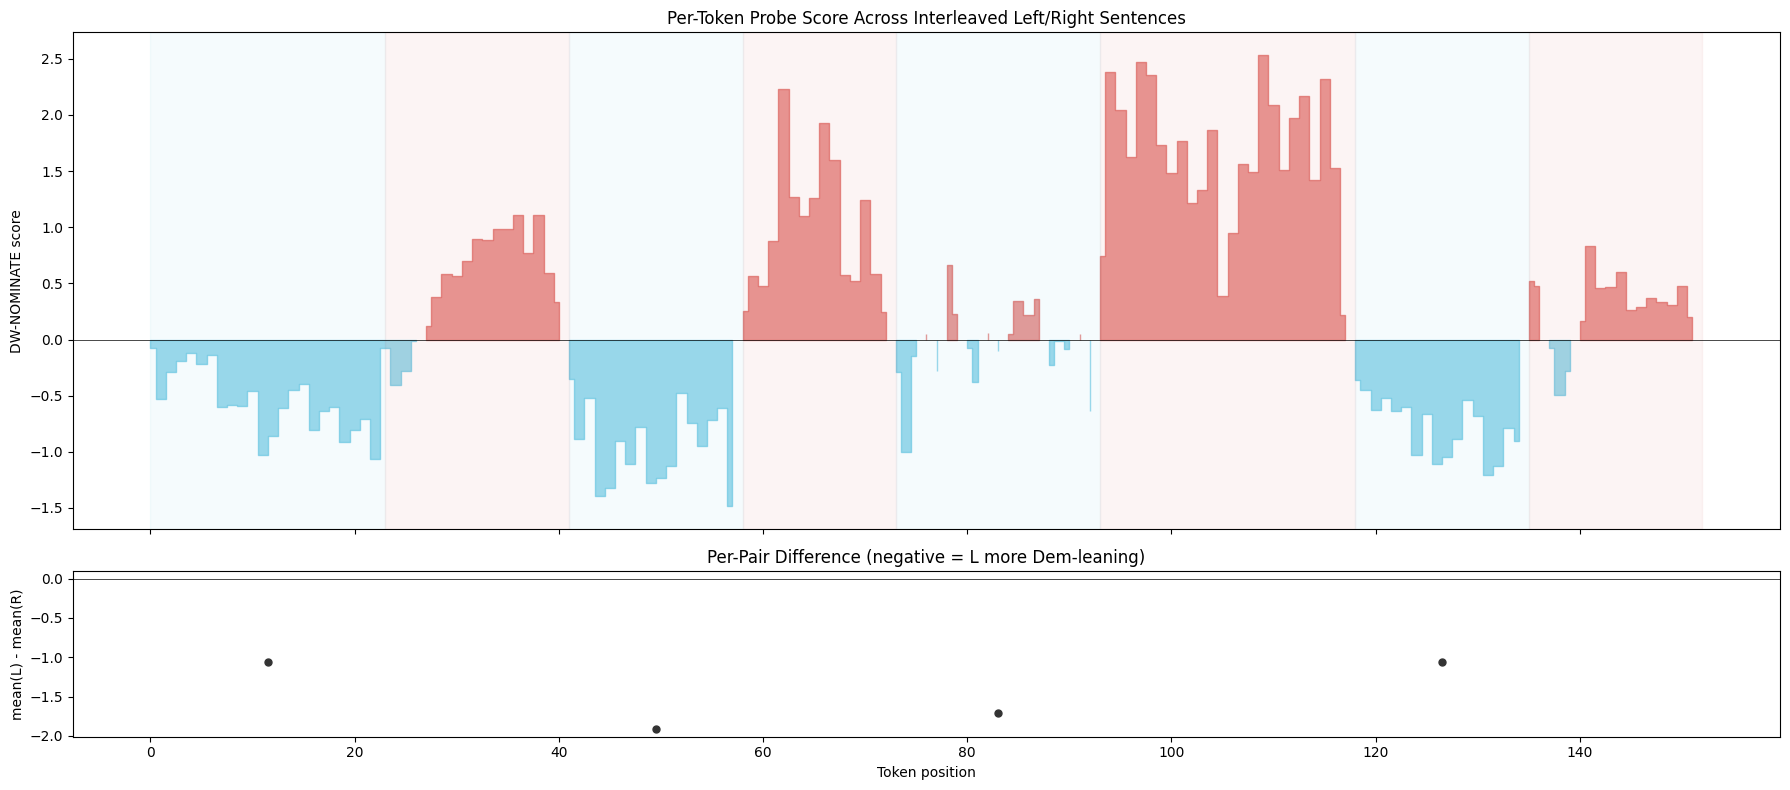

Overall mean: +0.1785
L - R (mean of per-pair diffs): -1.4387


In [13]:
parts = []
boundaries = []
pos = 0
for _, row in few.iterrows():
    ltxt = f"LEFT: {row['l']}"
    rtxt = f"RIGHT: {row['r']}"
    lt, _ = tokenize_and_score(ltxt)
    rt, _ = tokenize_and_score(rtxt)
    parts.append(ltxt)
    parts.append(rtxt)
    boundaries.append((pos, "L", row["topic"]))
    pos += len(lt)
    boundaries.append((pos, "R", row["topic"]))
    pos += len(rt)

full = " ".join(parts)
tokens, scores = tokenize_and_score(full)
print(f"Tokens: {len(tokens)}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 8), sharex=True,
                               gridspec_kw={"height_ratios": [3, 1]})
x = np.arange(len(scores))
ax1.fill_between(x, 0, scores, where=scores > 0, color="#d9534f", alpha=0.6, step="mid")
ax1.fill_between(x, 0, scores, where=scores < 0, color="#5bc0de", alpha=0.6, step="mid")
ax1.axhline(0, color="black", linewidth=0.5)
ax1.set_ylabel("DW-NOMINATE score")
ax1.set_title("Per-Token Probe Score Across Interleaved Left/Right Sentences")

for i in range(len(boundaries)):
    bpos, bside, btop = boundaries[i]
    next_b = boundaries[i+1][0] if i+1 < len(boundaries) else len(scores)
    color = "#5bc0de" if bside == "L" else "#d9534f"
    ax1.axvspan(bpos, min(next_b, len(scores)), alpha=0.06, color=color)

diffs = []
for i in range(0, len(boundaries), 2):
    if i+1 < len(boundaries):
        ls = scores[boundaries[i][0]:boundaries[i+1][0]]
        rs_end = boundaries[i+2][0] if i+2 < len(boundaries) else len(scores)
        rs = scores[boundaries[i+1][0]:rs_end]
        d = np.nanmean(ls) - np.nanmean(rs)
        diffs.append(d)
        mid = (boundaries[i][0] + boundaries[i+1][0]) / 2
        ax2.scatter(mid, d, c="#333", s=25, zorder=5)

ax2.axhline(0, color="black", linewidth=0.5)
ax2.set_ylabel("mean(L) - mean(R)")
ax2.set_xlabel("Token position")
ax2.set_title("Per-Pair Difference (negative = L more Dem-leaning)")
plt.tight_layout()
plt.show()

print(f"Overall mean: {np.nanmean(scores):+.4f}")
print(f"L - R (mean of per-pair diffs): {np.mean(diffs):+.4f}")

## Multi-Sample: Image Canvas vs Direct Text Correlation

Run N twinview pairs through BOTH pipelines:
1. **Image canvas**: render L/R text as an image, score vision tokens, extract per-sentence region means
2. **Direct text**: tokenize each sentence separately, compute per-sentence mean

Then compare: sentence-level and token-level correlation.

In [14]:
N_ITERS = 50         # each iter = 4 pairs = 8 sentences = one canvas image
PAIRS_PER_ITER = 4
random.seed(42)

records = []
all_iter_data = []  # store per-iteration grid info for optional visualization

sharp = tv_df['l'].apply(len) + tv_df['r'].apply(len)
keep = sharp[sharp < 400]  # skip unusually long pairs to avoid huge canvases
tv_filt = tv_df.loc[keep.index]

for it in range(N_ITERS):
    sample_pairs = tv_filt.sample(n=PAIRS_PER_ITER, random_state=it).reset_index(drop=True)

    # ---- Build interleaved canvas ----
    lines = []
    for _, row in sample_pairs.iterrows():
        lines.append((f"L: {row['l']}", "#5bc0de"))
        lines.append((f"R: {row['r']}", "#d9534f"))

    line_h = font.getbbox("Ag")[3] - font.getbbox("Ag")[1] + line_spacing

    wrapped_lines = []
    wrapped_colors = []
    wrapped_pair_idx = []
    wrapped_side = []
    pi = 0
    for text, clr in lines:
        words = text.split()
        cur = ""
        for w in words:
            test = cur + (" " if cur else "") + w
            if font.getbbox(test)[2] - font.getbbox(test)[0] > max_width - 20:
                wrapped_lines.append(cur)
                wrapped_colors.append(clr)
                wrapped_pair_idx.append(pi)
                wrapped_side.append("L" if "#5bc0de" in clr else "R")
                cur = w
            else:
                cur = test
        if cur:
            wrapped_lines.append(cur)
            wrapped_colors.append(clr)
            wrapped_pair_idx.append(pi)
            wrapped_side.append("L" if "#5bc0de" in clr else "R")
        if "#d9534f" in clr:
            pi += 1

    canvas_h = len(wrapped_lines) * line_h + 20
    canvas = Image.new("RGB", (max_width, canvas_h), "white")
    draw = ImageDraw.Draw(canvas)
    y = 10
    for text, clr in zip(wrapped_lines, wrapped_colors):
        draw.text((10, y), text, fill=clr, font=font)
        y += line_h

    # ---- Score via VLM ----
    msgs = [{"role": "user", "content": [
        {"type": "image", "image": canvas},
        {"type": "text", "text": "What political perspectives are expressed in this image?"},
    ]}]
    enc = processor.apply_chat_template(
        msgs, tokenize=True, add_generation_prompt=True,
        return_dict=True, return_tensors="pt",
    )
    inputs = {k: v.to(model.device) if isinstance(v, torch.Tensor) else v for k, v in enc.items()}

    image_token_id = processor.tokenizer.convert_tokens_to_ids("<|image_pad|>")
    input_ids = inputs["input_ids"][0].cpu().numpy()
    is_image = (input_ids == image_token_id) if image_token_id is not None else \
               np.zeros(len(input_ids), dtype=bool)

    from transformers.models.qwen2_vl.image_processing_qwen2_vl import smart_resize
    ip = processor.image_processor
    patch = ip.patch_size if hasattr(ip, 'patch_size') else 14
    merge = ip.merge_size if hasattr(ip, 'merge_size') else 2
    factor = patch * merge
    rh, rw = smart_resize(canvas.height, canvas.width, factor,
                          min_pixels=ip.size["shortest_edge"],
                          max_pixels=ip.size["longest_edge"])
    gh, gw = rh // factor, rw // factor

    all_scores = score_tokens(inputs)
    img_scores = all_scores[is_image]
    img_grid = img_scores.reshape(gh, gw)

    # ---- Map grid rows to pairs/sentences ----
    grid_row_height = rh / gh
    row_info = [(-1, "") for _ in range(gh)]
    for li in range(len(wrapped_lines)):
        y_start = 10 + li * line_h
        y_end = y_start + line_h - line_spacing
        row_start = int(y_start / grid_row_height)
        row_end = min(int(y_end / grid_row_height) + 1, gh)
        for r in range(row_start, row_end):
            if 0 <= r < gh:
                row_info[r] = (wrapped_pair_idx[li], wrapped_side[li])

    # ---- Extract per-sentence data ----
    for pp, (_, row) in enumerate(sample_pairs.iterrows()):
        for side, key in [("L", "l"), ("R", "r")]:
            # Text tokenization
            toks, tscores = tokenize_and_score(row[key])
            txt_mean = np.nanmean(tscores)

            # Image region
            img_rows = [r for r in range(gh) if row_info[r] == (pp, side)]
            if img_rows:
                img_region = img_grid[img_rows, :]
                img_mean = float(img_region.mean())
                img_flat = img_region.flatten().tolist()
            else:
                img_mean = float('nan')
                img_flat = []

            records.append({
                "iter": it, "pair_idx": pp, "side": side,
                "txt_scores": tscores.tolist() if len(tscores) > 0 else [],
                "txt_mean": txt_mean,
                "img_n_cells": len(img_flat),
                "img_mean": img_mean,
                "img_flat": img_flat,
            })

    if (it + 1) % 10 == 0:
        print(f"  iter {it+1}/{N_ITERS}  ({len(records)} sentences so far)")

df_records = pd.DataFrame(records)
valid = df_records.dropna(subset=["txt_mean", "img_mean"])
print(f"Done: {len(df_records)} total sentences, {len(valid)} valid ({N_ITERS} iters x {PAIRS_PER_ITER} pairs x 2)")
print(f"Image cells/sent: min={df_records['img_n_cells'].min()}, max={df_records['img_n_cells'].max()}, median={df_records['img_n_cells'].median():.0f}")
print(f"Text tokens/sent:  min={df_records['txt_scores'].apply(len).min()}, max={df_records['txt_scores'].apply(len).max()}")


  iter 10/50  (80 sentences so far)
  iter 20/50  (160 sentences so far)
  iter 30/50  (240 sentences so far)
  iter 40/50  (320 sentences so far)
  iter 50/50  (400 sentences so far)
Done: 400 total sentences, 400 valid (50 iters x 4 pairs x 2)
Image cells/sent: min=28, max=140, median=84
Text tokens/sent:  min=8, max=28


## Sentence-Level Correlation

For each L or R sentence, compute the mean text-token score and the mean image-region score.
Scatter and correlate.

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

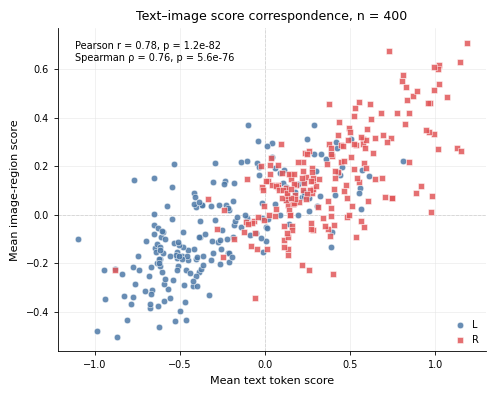

All sentences (n=400): Pearson r=0.7788 p=0.0000  Spearman rho=0.7584 p=0.0000
L only (n=200): Pearson r=0.7077 p=0.0000  Spearman rho=0.7164 p=0.0000
R only (n=200): Pearson r=0.6792 p=0.0000  Spearman rho=0.6329 p=0.0000


: 

In [ ]:
from scipy import stats
import matplotlib.pyplot as plt

valid = df_records.dropna(subset=["txt_mean", "img_mean"])

# Nature-like matplotlib styling
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.linewidth": 0.6,
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

fig, ax = plt.subplots(figsize=(5, 4))  # Nature single-column-ish size

# Muted, print-friendly colors
palette = {
    "L": "#4E79A7",  # muted blue
    "R": "#E15759",  # muted red
}
markers = {
    "L": "o",
    "R": "s",
}

for side in ["L", "R"]:
    sub = valid[valid["side"] == side]
    ax.scatter(
        sub["txt_mean"],
        sub["img_mean"],
        c=palette[side],
        marker=markers[side],
        s=22,
        edgecolors="white",
        linewidth=0.4,
        alpha=0.85,
        label=side,
        zorder=3,
    )

# Reference lines
ax.axhline(0, color="0.75", linewidth=0.6, linestyle="--", zorder=1)
ax.axvline(0, color="0.75", linewidth=0.6, linestyle="--", zorder=1)

# Correlations
r_all, p_all = stats.pearsonr(valid["txt_mean"], valid["img_mean"])
rho_all, p_rho_all = stats.spearmanr(valid["txt_mean"], valid["img_mean"])

label_str = (
    f"Pearson r = {r_all:.2f}, p = {p_all:.2g}\n"
    f"Spearman ρ = {rho_all:.2f}, p = {p_rho_all:.2g}"
)

ax.text(
    0.04,
    0.96,
    label_str,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=7,
)

# Labels and title
ax.set_xlabel("Mean text token score")
ax.set_ylabel("Mean image-region score")
ax.set_title(f"Text–image score correspondence, n = {len(valid)}", pad=6)

# Legend
leg = ax.legend(
    frameon=False,
    loc="lower right",
    handletextpad=0.3,
    borderaxespad=0.3,
)

# Remove top/right spines for Nature-ish minimalism
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Subtle grid, optional but publication-friendly
ax.grid(True, color="0.9", linewidth=0.4, zorder=0)

plt.tight_layout()

# Save publication-ready files
plt.savefig("text_image_correlation_nature_style.pdf", bbox_inches="tight")
plt.savefig("text_image_correlation_nature_style.png", dpi=600, bbox_inches="tight")

plt.show()

print(
    f"All sentences (n={len(valid)}): "
    f"Pearson r={r_all:.4f} p={p_all:.4f}  "
    f"Spearman rho={rho_all:.4f} p={p_rho_all:.4f}"
)

for side in ["L", "R"]:
    sub = valid[valid.side == side]
    r_side, p_side = stats.pearsonr(sub["txt_mean"], sub["img_mean"])
    rho_side, p_rho_side = stats.spearmanr(sub["txt_mean"], sub["img_mean"])

    print(
        f"{side} only (n={len(sub)}): "
        f"Pearson r={r_side:.4f} p={p_side:.4f}  "
        f"Spearman rho={rho_side:.4f} p={p_rho_side:.4f}"
    )

## Token-Level Correlation (with Resampling)

Text tokens and image grid cells have different cardinalities per sentence.
We interpolate both sequences to a shared length and correlate position-by-position.

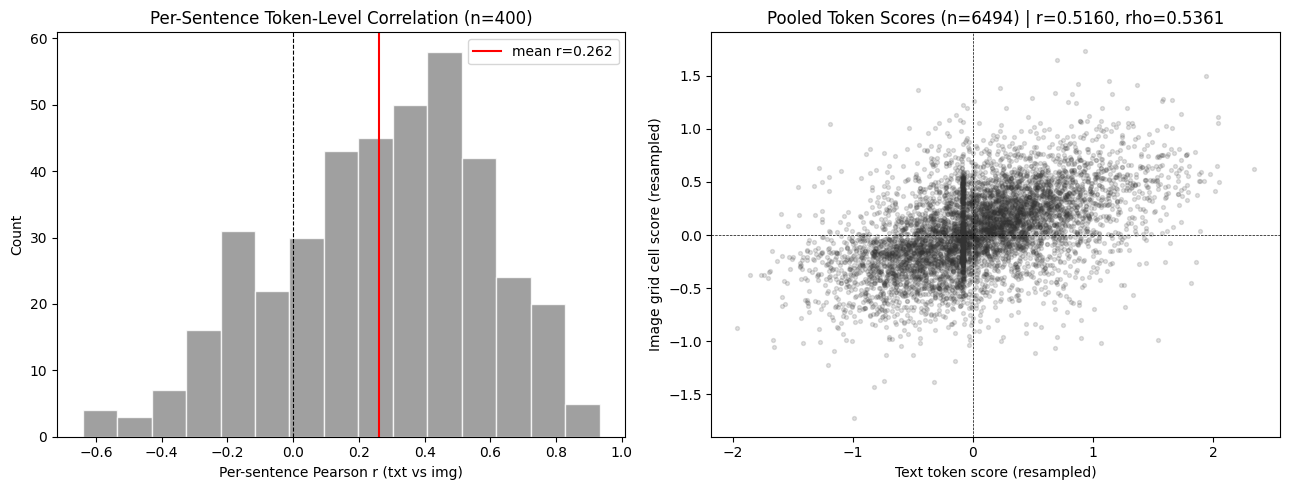

Pooled token-level:  Pearson r=0.5160 (p=0)  Spearman rho=0.5361 (p=0)
Per-sentence r:      mean=0.2620  median=0.3030  std=0.3189


In [16]:
# For each sentence: resample text tokens and image cells to min common length.

pooled_txt_all = []
pooled_img_all = []
per_sentence_rs = []

for _, rec in df_records.iterrows():
    txt_scores = np.array(rec["txt_scores"])
    img_flat = np.array(rec["img_flat"])

    if len(txt_scores) < 2 or len(img_flat) < 2:
        continue

    # Resample both to min length
    L_target = min(len(txt_scores), len(img_flat))
    L_target = max(2, L_target)

    txt_x = np.linspace(0, 1, len(txt_scores))
    img_x = np.linspace(0, 1, len(img_flat))
    new_x = np.linspace(0, 1, L_target)

    txt_interp = np.interp(new_x, txt_x, txt_scores)
    img_interp = np.interp(new_x, img_x, img_flat)

    pooled_txt_all.append(txt_interp)
    pooled_img_all.append(img_interp)

    r_sent, _ = stats.pearsonr(txt_interp, img_interp)
    per_sentence_rs.append({
        "pair_idx": rec["pair_idx"],
        "side": rec["side"],
        "r": r_sent,
        "n_txt": len(txt_scores),
        "n_img": len(img_flat),
        "L_target": L_target,
    })

pooled_txt = np.concatenate(pooled_txt_all)
pooled_img = np.concatenate(pooled_img_all)
r_pooled, p_pooled = stats.pearsonr(pooled_txt, pooled_img)
rho_pooled, p_rho_pooled = stats.spearmanr(pooled_txt, pooled_img)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: per-sentence r histogram
rs_df = pd.DataFrame(per_sentence_rs)
axes[0].hist(rs_df["r"], bins=15, color="#888888", edgecolor="white", alpha=0.8)
axes[0].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].axvline(rs_df["r"].mean(), color="red", linewidth=1.5, linestyle="-",
               label=f"mean r={rs_df["r"].mean():.3f}")
axes[0].set_xlabel("Per-sentence Pearson r (txt vs img)")
axes[0].set_ylabel("Count")
axes[0].set_title(f'Per-Sentence Token-Level Correlation (n={len(rs_df)})')
axes[0].legend()

# Plot 2: pooled scatter
axes[1].scatter(pooled_txt, pooled_img, alpha=0.15, s=8, c="#333")
axes[1].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[1].axvline(0, color="black", linewidth=0.5, linestyle="--")
axes[1].set_xlabel("Text token score (resampled)")
axes[1].set_ylabel("Image grid cell score (resampled)")
axes[1].set_title(f'Pooled Token Scores (n={len(pooled_txt)}) | r={r_pooled:.4f}, rho={rho_pooled:.4f}')

plt.tight_layout()
plt.show()

print(f"Pooled token-level:  Pearson r={r_pooled:.4f} (p={p_pooled:.3g})  Spearman rho={rho_pooled:.4f} (p={p_rho_pooled:.3g})")
print(f"Per-sentence r:      mean={rs_df["r"].mean():.4f}  median={rs_df["r"].median():.4f}  std={rs_df["r"].std():.4f}")


## Column-Level: Image Grid Columns vs Text Tokens

For each sentence, compute per-column mean image score (average across its rows),
treat as a spatial sequence, and correlate with text token scores.

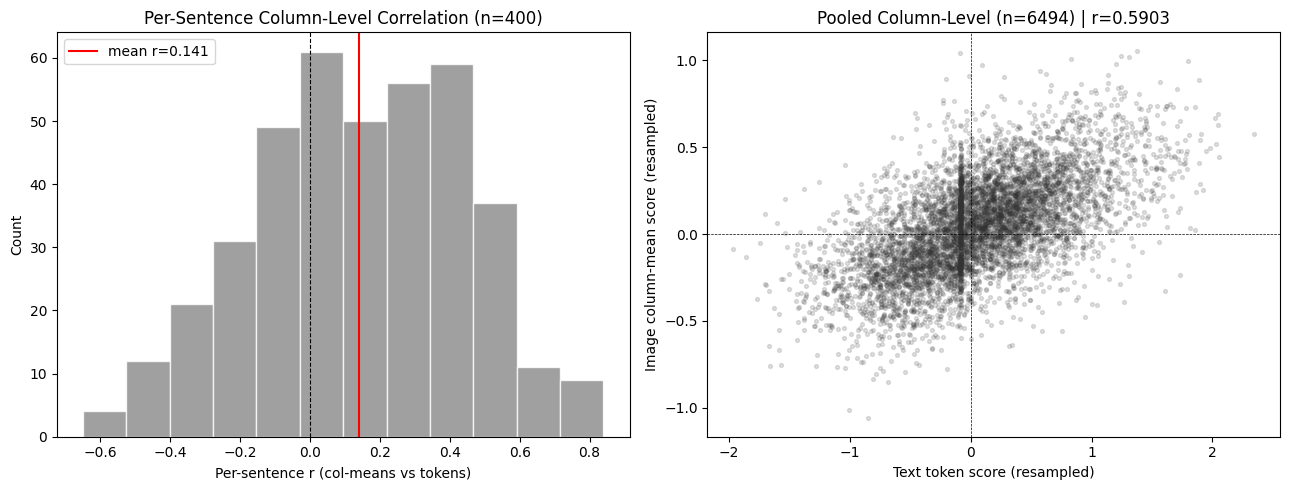

Column-level pooled: Pearson r=0.5903 (p=0)
Per-sentence column r: mean=0.1406  median=0.1538


In [17]:
# For each sentence: mean across rows -> gw column values, then correlate with text tokens.

col_pooled_txt = []
col_pooled_img = []
col_per_sent_rs = []

for _, rec in df_records.iterrows():
    txt_scores = np.array(rec["txt_scores"])

    if len(txt_scores) < 2 or rec["img_n_cells"] < 2:
        continue

    n_rows = rec["img_n_cells"] // gw
    if n_rows < 1:
        continue
    flat = np.array(rec["img_flat"])
    flat = flat[:n_rows * gw]
    if len(flat) < n_rows * gw:
        continue
    img_2d = flat.reshape(n_rows, gw)
    col_means = img_2d.mean(axis=0)  # gw values

    # Resample column means to match text token count
    L_target = min(len(txt_scores), len(col_means))
    L_target = max(2, L_target)

    txt_x = np.linspace(0, 1, len(txt_scores))
    col_x = np.linspace(0, 1, len(col_means))
    new_x = np.linspace(0, 1, L_target)

    txt_interp = np.interp(new_x, txt_x, txt_scores)
    col_interp = np.interp(new_x, col_x, col_means)

    col_pooled_txt.append(txt_interp)
    col_pooled_img.append(col_interp)

    r_col, _ = stats.pearsonr(txt_interp, col_interp)
    col_per_sent_rs.append({
        "pair_idx": rec["pair_idx"],
        "side": rec["side"],
        "r": r_col,
        "n_rows": n_rows,
        "gw": gw,
        "L_target": L_target,
    })

col_pooled_txt_arr = np.concatenate(col_pooled_txt)
col_pooled_img_arr = np.concatenate(col_pooled_img)
r_col_pooled, p_col_pooled = stats.pearsonr(col_pooled_txt_arr, col_pooled_img_arr)

col_rs_df = pd.DataFrame(col_per_sent_rs)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(col_rs_df["r"].dropna(), bins=12, color="#888888", edgecolor="white", alpha=0.8)
axes[0].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].axvline(col_rs_df["r"].mean(), color="red", linewidth=1.5,
               label=f"mean r={col_rs_df["r"].mean():.3f}")
axes[0].set_xlabel("Per-sentence r (col-means vs tokens)")
axes[0].set_ylabel("Count")
axes[0].set_title(f'Per-Sentence Column-Level Correlation (n={len(col_rs_df)})')
axes[0].legend()

axes[1].scatter(col_pooled_txt_arr, col_pooled_img_arr, alpha=0.15, s=8, c="#333")
axes[1].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[1].axvline(0, color="black", linewidth=0.5, linestyle="--")
axes[1].set_xlabel("Text token score (resampled)")
axes[1].set_ylabel("Image column-mean score (resampled)")
axes[1].set_title(f'Pooled Column-Level (n={len(col_pooled_txt_arr)}) | r={r_col_pooled:.4f}')

plt.tight_layout()
plt.show()

print(f"Column-level pooled: Pearson r={r_col_pooled:.4f} (p={p_col_pooled:.3g})")
print(f"Per-sentence column r: mean={col_rs_df["r"].mean():.4f}  median={col_rs_df["r"].median():.4f}")


## Summary Correlation Table

In [18]:
summary_rows = [
    {"Level": "Sentence (all)", "n": len(valid), "Pearson r": r_all, "p": p_all, "Spearman rho": rho_all},
    {"Level": "Sentence (L only)", "n": len(valid[valid.side=="L"]),
     "Pearson r": stats.pearsonr(valid[valid.side=="L"]["txt_mean"], valid[valid.side=="L"]["img_mean"])[0],
     "p": stats.pearsonr(valid[valid.side=="L"]["txt_mean"], valid[valid.side=="L"]["img_mean"])[1],
     "Spearman rho": stats.spearmanr(valid[valid.side=="L"]["txt_mean"], valid[valid.side=="L"]["img_mean"])[0]},
    {"Level": "Sentence (R only)", "n": len(valid[valid.side=="R"]),
     "Pearson r": stats.pearsonr(valid[valid.side=="R"]["txt_mean"], valid[valid.side=="R"]["img_mean"])[0],
     "p": stats.pearsonr(valid[valid.side=="R"]["txt_mean"], valid[valid.side=="R"]["img_mean"])[1],
     "Spearman rho": stats.spearmanr(valid[valid.side=="R"]["txt_mean"], valid[valid.side=="R"]["img_mean"])[0]},
    {"Level": "L-R diff", "n": len(pivot),
     "Pearson r": r_diff, "p": p_diff,
     "Spearman rho": rho_diff},
    {"Level": "Token (pooled, row-major)", "n": len(pooled_txt),
     "Pearson r": r_pooled, "p": p_pooled,
     "Spearman rho": rho_pooled},
    {"Level": "Token (pooled, col-means)", "n": len(col_pooled_txt_arr),
     "Pearson r": r_col_pooled, "p": p_col_pooled,
     "Spearman rho": stats.spearmanr(col_pooled_txt_arr, col_pooled_img_arr)[0]},
    {"Level": "Per-sentence token r (mean)", "n": len(rs_df),
     "Pearson r": rs_df["r"].mean(), "p": np.nan, "Spearman rho": np.nan},
    {"Level": "Per-sentence col r (mean)", "n": len(col_rs_df),
     "Pearson r": col_rs_df["r"].mean(), "p": np.nan, "Spearman rho": np.nan},
]
summary = pd.DataFrame(summary_rows).round(4)
display(summary)

# Also show per-sentence details
print("\nPer-sentence token-level r summary:")
display(pd.DataFrame(per_sentence_rs).describe().round(4))


,Level,n,Pearson r,p,Spearman rho
0,Sentence (all),400,0.7788,0.0000,0.7584
1,Sentence (L only),200,0.7077,0.0000,0.7164
2,Sentence (R only),200,0.6792,0.0000,0.6329
3,L-R diff,4,0.6214,0.3786,0.6000
4,"Token (pooled, row-major)",6494,0.5160,0.0000,0.5361
5,"Token (pooled, col-means)",6494,0.5903,0.0000,0.5906
6,Per-sentence token r (mean),400,0.2620,NaN,NaN
7,Per-sentence col r (mean),400,0.1406,NaN,NaN



Per-sentence token-level r summary:


,pair_idx,r,n_txt,n_img,L_target
count,400.0000,400.0000,400.0000,400.000,400.0000
mean,1.5000,0.2620,16.2350,74.480,16.2350
std,1.1194,0.3189,3.5399,19.105,3.5399
min,0.0000,-0.6404,8.0000,28.000,8.0000
25%,0.7500,0.0532,14.0000,56.000,14.0000
50%,1.5000,0.3030,16.0000,84.000,16.0000
75%,2.2500,0.4964,18.0000,84.000,18.0000
max,3.0000,0.9325,28.0000,140.000,28.0000
